In [1]:
import pandas as pd
import numpy as np
import json
import plotly.express as px
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import ast

# Load the dataset
df = pd.read_csv("Worldwide Travel Cities Dataset (Ratings and Climate).csv")



In [2]:
# Safely parse JSON-like strings into Python dictionaries
df['avg_temp_monthly'] = df['avg_temp_monthly'].apply(ast.literal_eval)

# Expand monthly temperatures into separate columns
monthly_temps = df['avg_temp_monthly'].apply(pd.Series)

# Rename columns for clarity (assuming 12 values for 12 months)
monthly_temps.columns = ['Jan_temp', 'Feb_temp', 'Mar_temp', 'Apr_temp', 'May_temp', 'Jun_temp',
                         'Jul_temp', 'Aug_temp', 'Sep_temp', 'Oct_temp', 'Nov_temp', 'Dec_temp']

# Merge back with original dataframe and drop original column
df = pd.concat([df.drop(columns=['avg_temp_monthly']), monthly_temps], axis=1)

# Preview the cleaned dataframe
print(df.head())

                                     id            city    country  \
0  c54acf38-3029-496b-8c7a-8343ad82785c           Milan      Italy   
1  0bd12654-ed64-424e-a044-7bc574bcf078  Yasawa Islands       Fiji   
2  73036cda-9134-46fc-a2c6-807782d59dfb        Whistler     Canada   
3  3872c9c0-6b6e-49e1-9743-f46bfe591b86      Guanajuato     Mexico   
4  e1ebc1b6-8798-422d-847a-22016faff3fd        Surabaya  Indonesia   

          region                                  short_description  \
0         europe  Chic streets lined with fashion boutiques, his...   
1        oceania  Crystal-clear waters, secluded beaches, and vi...   
2  north_america  Snow-capped peaks and lush forests create a se...   
3  north_america  Winding cobblestone streets and colorful facad...   
4           asia  Bustling streets filled with the aroma of loca...   

    latitude   longitude                      ideal_durations budget_level  \
0  45.464194    9.189635            ["Short trip","One week"]       Luxury

In [3]:
user_input = {
    'themes': ['Nature', 'Cuisine', 'Adventure'],
    'budget': 'Mid-range',
    'month': 'August'
}


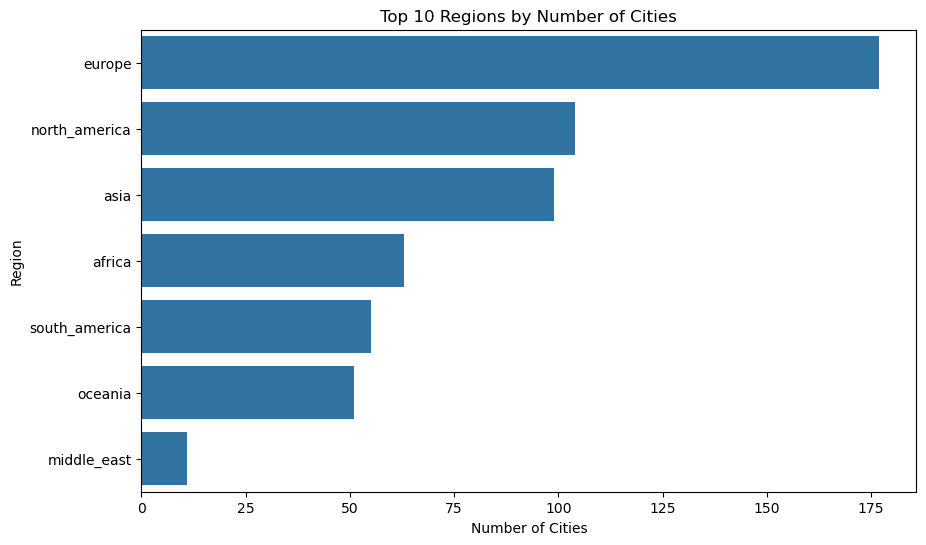

In [4]:
plt.figure(figsize=(10,6))
top_regions = df['region'].value_counts().head(10)
sns.barplot(x=top_regions.values, y=top_regions.index)
plt.title('Top 10 Regions by Number of Cities')
plt.xlabel('Number of Cities')
plt.ylabel('Region')
plt.show()



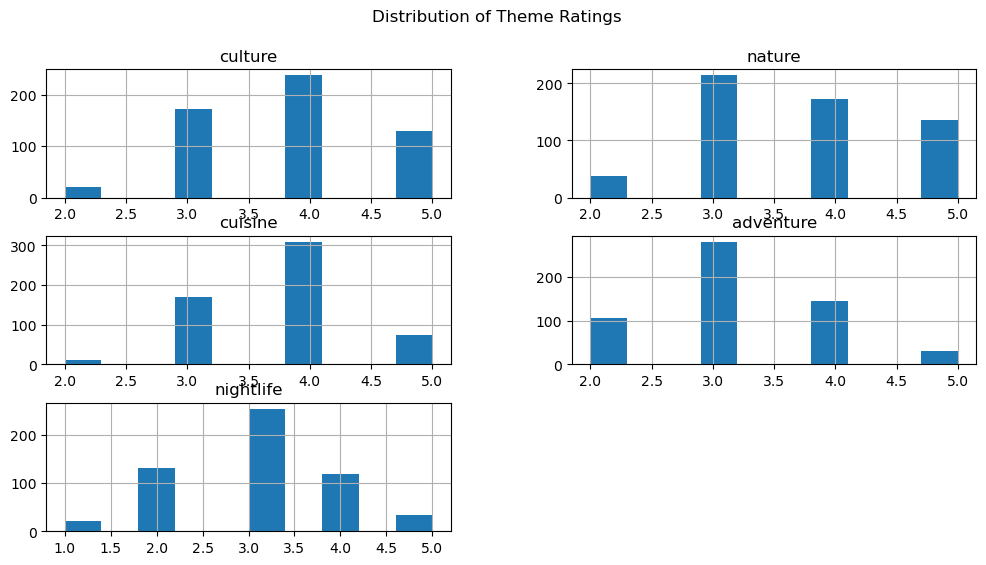

In [24]:
# Only use columns that exist in the dataframe
existing_rating_cols = [col for col in rating_cols if col in df.columns]

df[existing_rating_cols].hist(figsize=(12, 6))
plt.suptitle('Distribution of Theme Ratings')
plt.show()

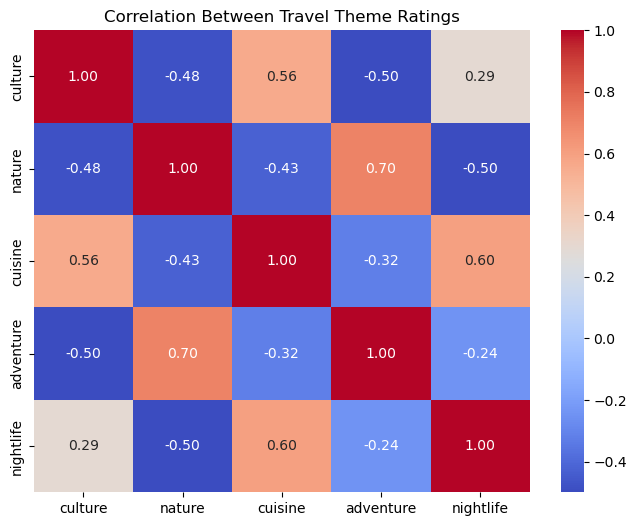

In [26]:
plt.figure(figsize=(8,6))
sns.heatmap(df[existing_rating_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Between Travel Theme Ratings")
plt.show()


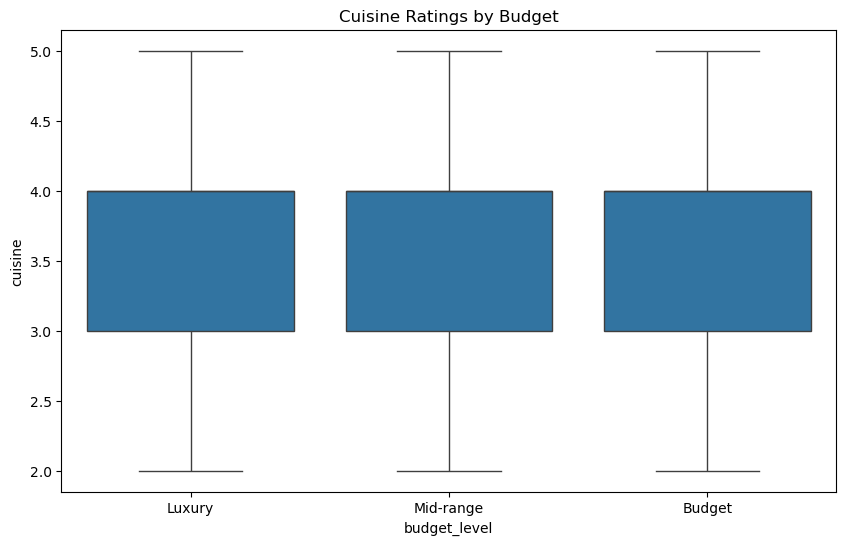

In [29]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='budget_level', y='cuisine')
plt.title('Cuisine Ratings by Budget')
plt.show()

In [8]:
# Use correct column names and extract temperature features for the selected month
selected_month = user_input['month']  # e.g., 'August'
month_col = selected_month[:3].capitalize() + '_temp'  # e.g., 'Aug_temp'

# Extract avg, min, max temperature for the selected month
df['avg_temp'] = df[month_col].apply(lambda x: x['avg'])
df['min_temp'] = df[month_col].apply(lambda x: x['min'])
df['max_temp'] = df[month_col].apply(lambda x: x['max'])

features = [
    'culture', 'adventure', 'nature', 'beaches', 'nightlife',
    'cuisine', 'wellness', 'urban',
    'avg_temp', 'min_temp', 'max_temp'
]

X = df[features]


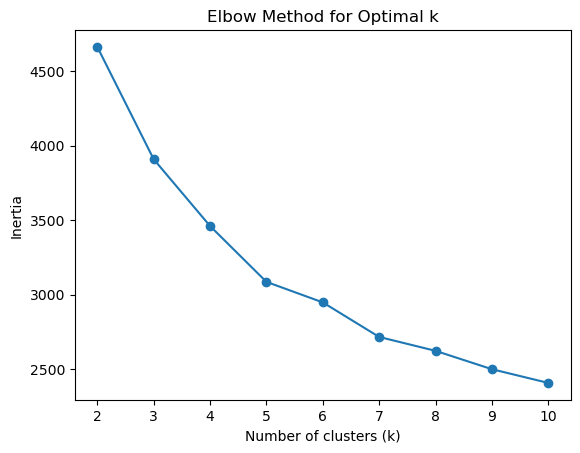

In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(k_range, inertia, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.show()

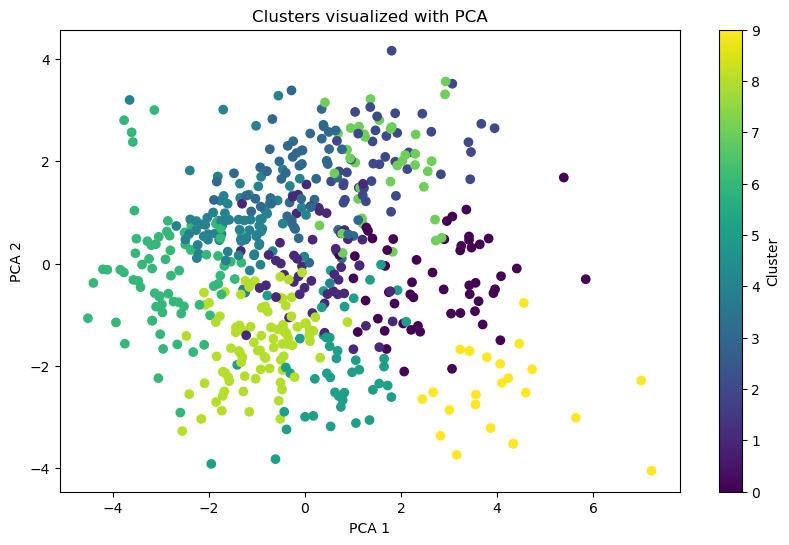

In [12]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
components = pca.fit_transform(X_scaled)

df['PCA1'] = components[:, 0]
df['PCA2'] = components[:, 1]

# Assign cluster labels to the dataframe
df['Cluster'] = kmeans.predict(X_scaled)

plt.figure(figsize=(10,6))
plt.scatter(df['PCA1'], df['PCA2'], c=df['Cluster'], cmap='viridis')
plt.title('Clusters visualized with PCA')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.colorbar(label='Cluster')
plt.show()


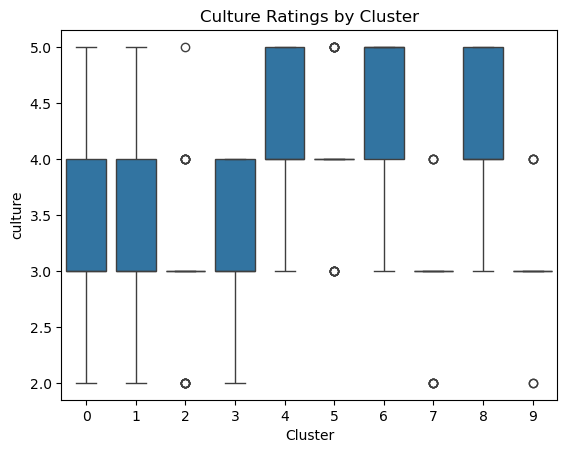

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=df, x='Cluster', y='culture')
plt.title('Culture Ratings by Cluster')
plt.show()

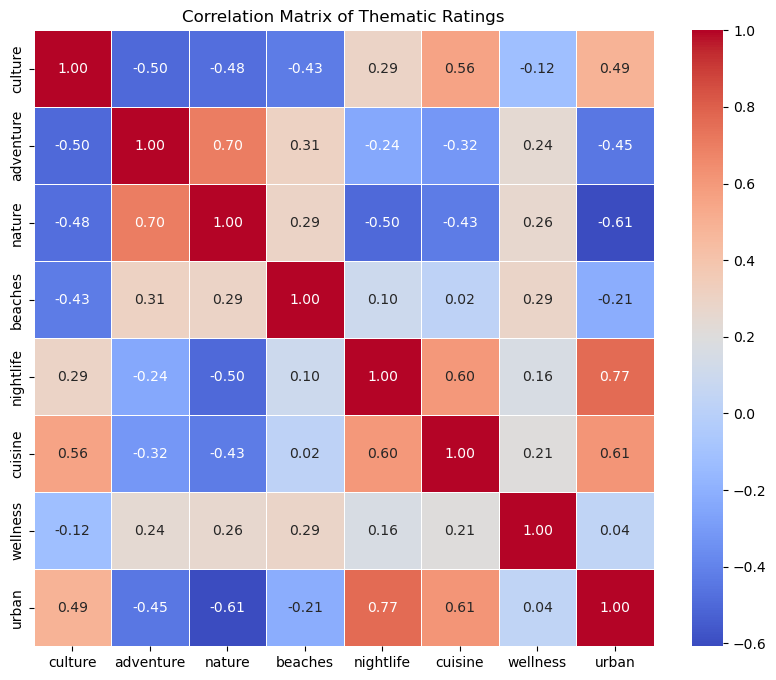

In [16]:
rating_columns = ['culture', 'adventure', 'nature', 'beaches', 'nightlife', 'cuisine', 'wellness', 'urban']
ratings_df = df[rating_columns]

correlation_matrix = ratings_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Thematic Ratings')
plt.show()


In [19]:
country_theme_summary = df.groupby('country')[['culture', 'adventure', 'nature', 'beaches', 'nightlife', 'cuisine', 'wellness', 'urban']].mean().sort_values('culture', ascending=False)

country_theme_summary.head()

,culture,adventure,nature,beaches,nightlife,cuisine,wellness,urban
country,,,,,,,,
Hong Kong,5.0,3.0,3.0,2.0,5.0,5.0,3.0,5.0
Iran,5.0,3.0,3.0,1.0,3.0,4.0,3.0,4.0
Guatemala,5.0,3.0,4.0,1.0,3.0,4.0,3.0,3.0
Malta,5.0,2.0,3.0,3.0,3.0,4.0,3.0,3.0
Cuba,5.0,3.0,3.5,3.0,3.5,4.0,2.5,2.5


In [20]:
city_counts = df['country'].value_counts().sort_values(ascending=False)
print(city_counts.head(10))


country
United States     50
Italy             19
Australia         17
Mexico            15
France            15
Canada            14
United Kingdom    14
Spain             12
Germany           11
Portugal          11
Name: count, dtype: int64


In [24]:
top_culture_by_region = df.loc[df.groupby('region')['culture'].idxmax()][['region', 'city', 'culture']]
print(top_culture_by_region)

top_culture_by_nightlife = df.loc[df.groupby('region')['nightlife'].idxmax()][['region', 'city', 'nightlife']]
print(top_culture_by_nightlife)

top_culture_by_cuisine = df.loc[df.groupby('region')['cuisine'].idxmax()][['region', 'city', 'cuisine']]
print(top_culture_by_cuisine)

top_culture_by_nature = df.loc[df.groupby('region')['nature'].idxmax()][['region', 'city', 'nature']]
print(top_culture_by_nature)

           region        city  culture
53         africa         Fès        5
14           asia       Bagan        5
0          europe       Milan        5
31    middle_east       Petra        5
3   north_america  Guanajuato        5
40        oceania   Melbourne        5
71  south_america   Cartagena        5
            region            city  nightlife
162         africa       Cape Town          4
23            asia           Seoul          5
16          europe       Amsterdam          5
410    middle_east           Dubai          5
17   north_america        New York          5
40         oceania       Melbourne          4
50   south_america  Rio de Janeiro          5
            region       city  cuisine
403         africa  Marrakesh        5
23            asia      Seoul        5
0           europe      Milan        5
115    middle_east      Amman        4
17   north_america   New York        5
40         oceania  Melbourne        5
261  south_america  Sao Paulo        5
        

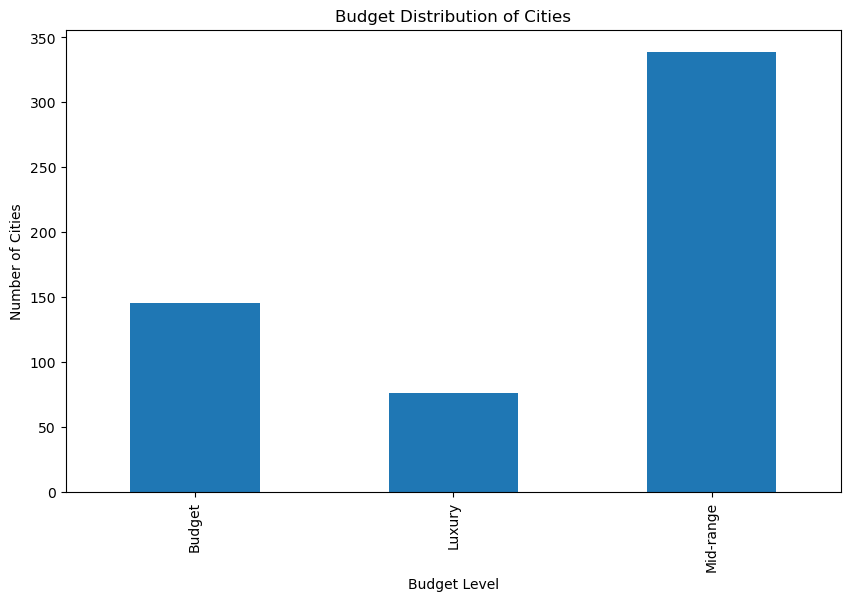

In [26]:
budget_distribution = df['budget_level'].value_counts().sort_index()
budget_distribution.plot(kind='bar', figsize=(10, 6))
plt.title('Budget Distribution of Cities')
plt.xlabel('Budget Level')
plt.ylabel('Number of Cities')
plt.show()  

In [28]:
features = ['culture', 'adventure', 'nature', 'beaches', 'nightlife',
            'cuisine', 'wellness', 'urban',]
df_selected = df[features].copy()
df_selected = df_selected.fillna(df_selected.mean())

In [31]:
df['Cluster'] = kmeans.labels_

# Use the correct column name 'Cluster' and valid feature columns
cluster_summary = df.groupby('Cluster')[features].mean()
print(cluster_summary)

          culture  adventure    nature   beaches  nightlife   cuisine  \
Cluster                                                                 
0        3.500000   4.074074  4.796296  1.833333   2.203704  3.055556   
1        3.634615   2.692308  3.346154  1.519231   2.500000  3.096154   
2        3.024390   3.829268  4.585366  3.170732   1.926829  3.000000   
3        3.285714   3.535714  3.964286  4.553571   3.553571  4.000000   
4        4.421687   2.807229  3.409639  1.867470   2.674699  4.084337   
5        4.000000   3.239130  3.739130  2.804348   3.521739  4.021739   
6        4.513158   2.815789  2.763158  2.144737   4.171053  4.644737   
7        2.973684   3.868421  4.894737  3.921053   2.500000  3.605263   
8        4.322222   2.444444  3.111111  1.388889   3.411111  4.011111   
9        3.083333   4.250000  4.750000  2.041667   2.541667  3.166667   

         wellness     urban  
Cluster                      
0        3.092593  2.203704  
1        2.288462  2.788462  
2  

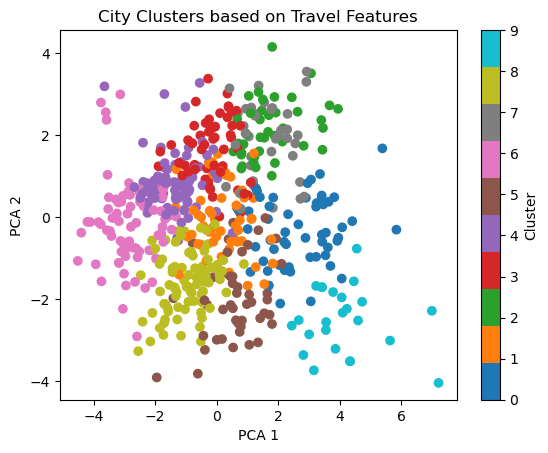

In [33]:
import matplotlib.pyplot as plt

plt.scatter(components[:, 0], components[:, 1], c=kmeans.labels_, cmap='tab10')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('City Clusters based on Travel Features')
plt.colorbar(label='Cluster')
plt.show()


In [48]:
rating_columns = ['culture', 'adventure', 'nature', 'beaches', 'nightlife', 'cuisine', 'wellness', 'urban']

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_scaled = scaler.fit_transform(df[rating_columns])



In [47]:
from sklearn.metrics.pairwise import cosine_similarity

print("Rate the following themes from 0 (not important) to 5 (very important):")
user_input = {}
for col in rating_columns:
    while True:
        try:
            val = float(input(f"{col}: "))
            if 0 <= val <= 5:
                user_input[col] = val
                break
            else:
                print("Enter a value between 0 and 5.")
        except ValueError:
            print("Invalid input. Please enter a number.")

# Convert input to vector and scale
user_vec = np.array([user_input[col] for col in rating_columns]).reshape(1, -1)
user_vec_scaled = scaler.transform(user_vec)

# Calculate cosine similarity
similarities = cosine_similarity(user_vec_scaled, X_scaled)[0]

# Attach similarity scores
df['Similarity'] = similarities

# Show top recommendations
top_n = 10
top_matches = df.sort_values(by='Similarity', ascending=False).head(top_n)

print(f"\nTop {top_n} Travel Recommendations:\n")
print(top_matches[['city', 'country', 'Similarity'] + rating_columns])

Rate the following themes from 0 (not important) to 5 (very important):

Top 10 Travel Recommendations:

            city               country  Similarity  culture  adventure  \
200    San Diego         United States    0.866217        4          4   
424    Vancouver                Canada    0.838019        4          4   
410        Dubai  United Arab Emirates    0.819433        4          4   
213     Honolulu         United States    0.805086        4          4   
484      Antalya                Turkey    0.788082        4          4   
40     Melbourne             Australia    0.787775        5          3   
23         Seoul           South Korea    0.771274        5          3   
96     Singapore             Singapore    0.759961        4          3   
414  Los Angeles         United States    0.738396        4          3   
105     Budapest               Hungary    0.715644        5          3   

     nature  beaches  nightlife  cuisine  wellness  urban  
200       4        5

/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
